# AI-Based Athlete Recovery, Tracking and Training Planner
## Recovery Score Prediction — ML Notebook

**Updated dataset:** `final_athlete_recovery_dataset.csv`

**Prediction target:** `Recovery_Score` (regression, 0–100 scale).

This notebook follows the supplied merge report and data dictionary. The final dataset contains 23,799 rows, 49 columns, and 456 unique athletes. The sources are synthetic/simulated, were stacked rather than row-matched, and contain substantial cross-source model-filled feature cells.

### ML strategy

- Use `Recovery_Score` as a continuous regression target.
- Never use athlete identifiers or metadata as model features.
- Use the supplied `Split_Group` so an athlete cannot occur in both development and final test data.
- Use `GroupKFold` for model comparison and hyperparameter tuning.
- Report overall and source-wise D1/D3 results.
- Compare the full aligned feature set with a sensitivity model that removes heavily cross-source-filled columns.
- Save the preprocessing + model pipeline as one `.joblib` artifact for Django integration.

> **Limitation:** These data are prototype/synthetic data, not clinical or real-world evidence. The supplied merge report also notes different source definitions and about 28.3% synthetic cross-source feature fills.


## 1. Install required packages

In [21]:
# Cell 1: Install packages

!pip install -q pandas numpy scikit-learn joblib openpyxl


## 2. Import libraries

In [22]:
# Cell 2: Imports

import os
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import (
    GroupKFold,
    cross_validate,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")


Libraries imported successfully.


## 3. Mount Google Drive

In [23]:
# Cell 3: Mount Google Drive

drive.mount("/content/drive")

print("Google Drive mounted.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.


## 4. Locate the updated dataset

The notebook searches `MyDrive` for the exact updated dataset filename rather than assuming a particular subfolder.


In [24]:
# Cell 4: Find dataset

DATASET_NAME = "final_athlete_recovery_dataset.csv"
DATA_PATH = None

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file == DATASET_NAME:
            DATA_PATH = os.path.join(root, file)
            break
    if DATA_PATH is not None:
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        f"Could not find '{DATASET_NAME}' under MyDrive."
    )

print("Dataset found:")
print(DATA_PATH)


Dataset found:
/content/drive/MyDrive/final_athlete_recovery_dataset.csv


## 5. Load the updated dataset

In [25]:
# Cell 5: Load dataset

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())


Dataset loaded successfully.
Shape: (23799, 49)


,Athlete_Key,Time_Index,Source_Dataset,Split_Group,Sport_Detail,Imputed_Columns,Injury_Occurred,Age,Gender,BMI,...,Joint_Angles,Gait_Speed,Cadence,Jump_Height,Ground_Reaction_Force,Range_Of_Motion,Ambient_Temperature,Humidity,Altitude,Recovery_Score
0,D1_1000,1,D1_Recovery,train,Team Sport,NaN,NaN,28,Male,23.5,...,118.4,1.91,89,0.47,1736,126.6,25.5,59.6,287,51.1
1,D1_1000,2,D1_Recovery,train,Team Sport,NaN,NaN,28,Male,23.3,...,113.3,1.86,83,0.48,1644,125.8,23.8,61.0,270,63.7
2,D1_1000,3,D1_Recovery,train,Team Sport,NaN,NaN,28,Male,24.0,...,120.7,1.86,88,0.47,1702,127.4,25.5,57.2,276,71.0
3,D1_1000,4,D1_Recovery,train,Team Sport,NaN,NaN,28,Male,23.6,...,119.8,1.95,88,0.49,1745,125.0,24.4,56.0,326,37.2
4,D1_1000,5,D1_Recovery,train,Team Sport,NaN,NaN,28,Male,23.6,...,116.7,1.87,90,0.48,1721,126.5,25.7,60.5,305,12.3


## 6. Optional: locate the data dictionary

In [26]:
# Cell 6: Locate optional data dictionary

DATA_DICTIONARY_NAME = "data_dictionary.csv"
DATA_DICTIONARY_PATH = None

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file == DATA_DICTIONARY_NAME:
            DATA_DICTIONARY_PATH = os.path.join(root, file)
            break
    if DATA_DICTIONARY_PATH is not None:
        break

if DATA_DICTIONARY_PATH:
    data_dictionary = pd.read_csv(DATA_DICTIONARY_PATH)
    print("Data dictionary found:")
    print(DATA_DICTIONARY_PATH)
    display(data_dictionary.head(10))
else:
    data_dictionary = None
    print("Data dictionary not found. Continuing with the validated dataset schema.")


Data dictionary found:
/content/drive/MyDrive/data_dictionary.csv


,Final_Column,Original_Column,Source_Dataset,Data_Type,Unit,Description,Transformation,ML_Role
0,Athlete_Key,D1: Athlete_ID | D3: athlete_id,Both (D1 + D3),string,id,Unique athlete key (source prefix + original i...,Prefix D1_/D3_ added; raw id NOT used as feature,Identifier
1,Time_Index,D1: Day | D3: session_id,Both (D1 + D3),int64,day / session #,Position of the observation in the athlete tim...,Renamed; D3 session order ASSUMED chronological,Identifier
2,Source_Dataset,-,Derived / Added,string,category,Which source the row comes from (D1_Recovery /...,Added,Feature
3,Split_Group,-,Derived / Added,string,category,Suggested train/test assignment by athlete (80...,Added (GroupShuffleSplit by Athlete_Key),Metadata
4,Sport_Detail,D1: Sport_Type | D3: sport_type,Both (D1 + D3),string,category,Original sport label before harmonising,Copied,Metadata
5,Imputed_Columns,-,Derived / Added,string,text,Columns of this row whose missing values were ...,Added,Metadata
6,Injury_Occurred,D3: injury_occurred,D3 (multimodal_sports_injury_dataset.csv),float64,0/1/2,"D3 only: 0 Healthy, 1 Low Risk, 2 Injured. Opt...",Renamed; left empty for D1 (not fabricated),Metadata
7,Age,D1: Age | D3: age,Both (D1 + D3),int64,years,Athlete age,Renamed,Feature
8,Gender,D1: Gender | D3: gender,Both (D1 + D3),string,category,Male / Female / Non-binary (non-binary exists ...,Renamed,Feature
9,BMI,D3: bmi,D3 (multimodal_sports_injury_dataset.csv),float64,kg/m2,Body mass index (athlete-constant in D3),D3 original; D1 cross-source model fill,Feature


## 7. Inspect dataset structure

In [27]:
# Cell 7: Structure

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nColumns:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

print("\nData types:")
display(df.dtypes.to_frame("dtype"))


Rows: 23799
Columns: 49

Columns:
0: Athlete_Key
1: Time_Index
2: Source_Dataset
3: Split_Group
4: Sport_Detail
5: Imputed_Columns
6: Injury_Occurred
7: Age
8: Gender
9: BMI
10: Sport_Type
11: Training_Type
12: Training_Duration_Min
13: Training_Intensity
14: Training_Load
15: Training_Load_7d_Avg
16: ACWR
17: Fatigue_Index
18: Playing_Surface
19: Sleep_Duration_Hours
20: Sleep_Quality
21: Sleep_Deficit
22: Sleep_Duration_7d_Avg
23: Resting_Heart_Rate
24: Resting_HR_7d_Avg
25: Heart_Rate
26: HRV_ms
27: HRV_7d_Avg
28: Body_Temperature
29: Hydration_Level
30: Stress_Level
31: Stress_Index
32: Mood_Score
33: Muscle_Soreness
34: Energy_Level
35: Caffeine_Intake_mg
36: Training_to_Recovery_Ratio
37: Step_Count
38: Muscle_Activity
39: Joint_Angles
40: Gait_Speed
41: Cadence
42: Jump_Height
43: Ground_Reaction_Force
44: Range_Of_Motion
45: Ambient_Temperature
46: Humidity
47: Altitude
48: Recovery_Score

Data types:


,dtype
Athlete_Key,object
Time_Index,int64
Source_Dataset,object
Split_Group,object
Sport_Detail,object
Imputed_Columns,object
Injury_Occurred,float64
Age,int64
Gender,object
BMI,float64


## 8. Validate target and key columns

In [28]:
# Cell 8: Validate target and split columns

TARGET_COLUMN = "Recovery_Score"

required_columns = [
    "Athlete_Key",
    "Time_Index",
    "Source_Dataset",
    "Split_Group",
    TARGET_COLUMN
]

missing = [
    col for col in required_columns
    if col not in df.columns
]

if missing:
    raise ValueError(
        "Required columns missing: " + ", ".join(missing)
    )

print("Target:", TARGET_COLUMN)
print("Target type:", df[TARGET_COLUMN].dtype)

display(df[TARGET_COLUMN].describe())


Target: Recovery_Score
Target type: float64


,Recovery_Score
count,23799.000000
mean,53.040250
std,21.855379
min,0.000000
25%,38.600000
50%,53.000000
75%,68.000000
max,100.000000


## 9. Data-quality checks

In [29]:
# Cell 9: Data quality

print("Exact duplicate rows:", df.duplicated().sum())
print(
    "Duplicate (Athlete_Key, Time_Index) pairs:",
    df.duplicated(["Athlete_Key", "Time_Index"]).sum()
)
print("Unique athletes:", df["Athlete_Key"].nunique())

print("\nMissing values:")
display(
    df.isna().sum().sort_values(ascending=False).to_frame("missing_values")
)

print("\nMissing Recovery_Score:", df[TARGET_COLUMN].isna().sum())


Exact duplicate rows: 0
Duplicate (Athlete_Key, Time_Index) pairs: 0
Unique athletes: 456

Missing values:


,missing_values
Imputed_Columns,20503
Injury_Occurred,8379
Athlete_Key,0
Time_Index,0
Source_Dataset,0
Sport_Detail,0
Split_Group,0
Age,0
Gender,0
BMI,0



Missing Recovery_Score: 0


## 10. Recovery score distribution

Minimum: 0.0
Maximum: 100.0
Mean: 53.04
Median: 53.0
Std: 21.855


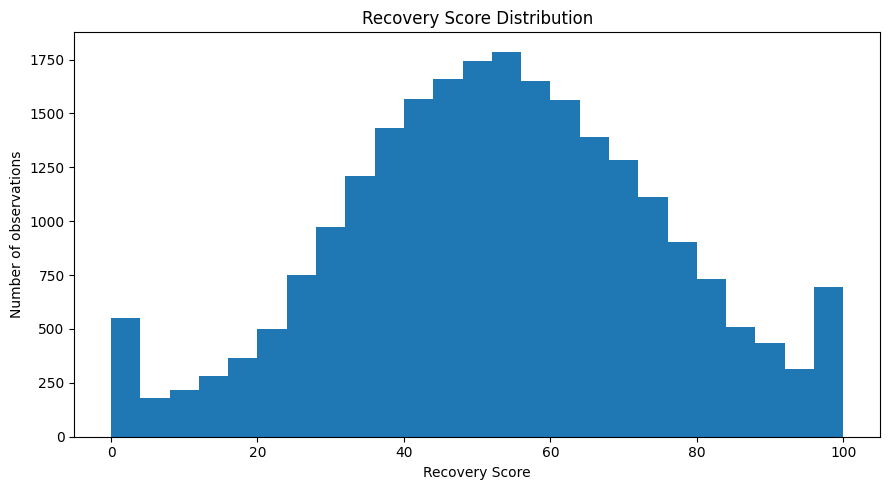

In [30]:
# Cell 10: Target distribution

print("Minimum:", df[TARGET_COLUMN].min())
print("Maximum:", df[TARGET_COLUMN].max())
print("Mean:", round(df[TARGET_COLUMN].mean(), 3))
print("Median:", round(df[TARGET_COLUMN].median(), 3))
print("Std:", round(df[TARGET_COLUMN].std(), 3))

plt.figure(figsize=(9, 5))
plt.hist(df[TARGET_COLUMN], bins=25)
plt.xlabel("Recovery Score")
plt.ylabel("Number of observations")
plt.title("Recovery Score Distribution")
plt.tight_layout()
plt.show()


## 11. Source-level target summary

In [31]:
# Cell 11: Source summary

source_summary = (
    df.groupby("Source_Dataset")[TARGET_COLUMN]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(3)
)

display(source_summary)


,count,mean,median,std,min,max
Source_Dataset,,,,,,
D1_Recovery,8379,49.061,48.9,27.926,0.0,100.0
D3_Multimodal,15420,55.202,54.4,17.326,8.9,98.0


## 12. Define model features

Identifiers and metadata are excluded:
- `Athlete_Key`
- `Time_Index`
- `Split_Group`
- `Sport_Detail`
- `Imputed_Columns`
- `Injury_Occurred`

`Source_Dataset` is retained because the supplied data dictionary marks it as a feature, while the merge report notes that it can capture source-specific offsets.


In [32]:
# Cell 12: Feature selection

excluded_columns = [
    "Athlete_Key",
    "Time_Index",
    "Split_Group",
    "Sport_Detail",
    "Imputed_Columns",
    "Injury_Occurred",
    TARGET_COLUMN
]

feature_columns = [
    col for col in df.columns
    if col not in excluded_columns
]

X = df[feature_columns].copy()
y = df[TARGET_COLUMN].copy()

print("Number of features:", len(feature_columns))
print(feature_columns)


Number of features: 42
['Source_Dataset', 'Age', 'Gender', 'BMI', 'Sport_Type', 'Training_Type', 'Training_Duration_Min', 'Training_Intensity', 'Training_Load', 'Training_Load_7d_Avg', 'ACWR', 'Fatigue_Index', 'Playing_Surface', 'Sleep_Duration_Hours', 'Sleep_Quality', 'Sleep_Deficit', 'Sleep_Duration_7d_Avg', 'Resting_Heart_Rate', 'Resting_HR_7d_Avg', 'Heart_Rate', 'HRV_ms', 'HRV_7d_Avg', 'Body_Temperature', 'Hydration_Level', 'Stress_Level', 'Stress_Index', 'Mood_Score', 'Muscle_Soreness', 'Energy_Level', 'Caffeine_Intake_mg', 'Training_to_Recovery_Ratio', 'Step_Count', 'Muscle_Activity', 'Joint_Angles', 'Gait_Speed', 'Cadence', 'Jump_Height', 'Ground_Reaction_Force', 'Range_Of_Motion', 'Ambient_Temperature', 'Humidity', 'Altitude']


## 13. Provenance-aware sensitivity set

The supplied merge report identifies these columns as having more than 50% cross-source model fills:

`Training_Type`, `Sleep_Duration_Hours`, `Resting_Heart_Rate`, `HRV_ms`, `Mood_Score`, `Muscle_Soreness`, `Energy_Level`, `Caffeine_Intake_mg`.

The primary model uses the full aligned feature set. A later sensitivity experiment removes these heavily filled columns.


In [33]:
# Cell 13: Reduced sensitivity feature set

heavily_filled_columns = [
    "Training_Type",
    "Sleep_Duration_Hours",
    "Resting_Heart_Rate",
    "HRV_ms",
    "Mood_Score",
    "Muscle_Soreness",
    "Energy_Level",
    "Caffeine_Intake_mg"
]

reduced_feature_columns = [
    col for col in feature_columns
    if col not in heavily_filled_columns
]

print("Full feature count:", len(feature_columns))
print("Reduced feature count:", len(reduced_feature_columns))
print("\nRemoved columns:")
print([c for c in heavily_filled_columns if c in feature_columns])


Full feature count: 42
Reduced feature count: 34

Removed columns:
['Training_Type', 'Sleep_Duration_Hours', 'Resting_Heart_Rate', 'HRV_ms', 'Mood_Score', 'Muscle_Soreness', 'Energy_Level', 'Caffeine_Intake_mg']


## 14. Verify athlete-wise split assignment

In [34]:
# Cell 14: Validate Split_Group

print("Split_Group counts:")
display(df["Split_Group"].value_counts())

athlete_split = (
    df[["Athlete_Key", "Split_Group"]]
      .drop_duplicates()
      .groupby("Athlete_Key")["Split_Group"]
      .nunique()
)

multi_split_athletes = (athlete_split > 1).sum()

print(
    "Athletes assigned to more than one split:",
    multi_split_athletes
)

if multi_split_athletes:
    raise ValueError(
        "Athlete-wise split is invalid because some athletes occur in multiple Split_Group values."
    )


Split_Group counts:


,count
Split_Group,
train,18962
test,4837


Athletes assigned to more than one split: 0


## 15. Create development and final test sets

The supplied `Split_Group` is used directly. This prevents the same athlete from being present in development and final test data.


In [35]:
# Cell 15: Development/final test split

train_mask = df["Split_Group"].astype(str).str.lower().eq("train")
test_mask = df["Split_Group"].astype(str).str.lower().isin(["test", "validation"])

if train_mask.sum() == 0 or test_mask.sum() == 0:
    raise ValueError(
        "Expected Split_Group to contain train and test/validation assignments."
    )

X_dev = df.loc[train_mask, feature_columns].copy()
y_dev = df.loc[train_mask, TARGET_COLUMN].copy()

X_final_test = df.loc[test_mask, feature_columns].copy()
y_final_test = df.loc[test_mask, TARGET_COLUMN].copy()

groups_dev = df.loc[train_mask, "Athlete_Key"].copy()

train_athletes = set(df.loc[train_mask, "Athlete_Key"])
test_athletes = set(df.loc[test_mask, "Athlete_Key"])

print("Development rows:", len(X_dev))
print("Final test rows:", len(X_final_test))
print("Development athletes:", len(train_athletes))
print("Final test athletes:", len(test_athletes))
print(
    "Athlete overlap:",
    len(train_athletes.intersection(test_athletes))
)


Development rows: 18962
Final test rows: 4837
Development athletes: 364
Final test athletes: 92
Athlete overlap: 0


## 16. Detect numerical and categorical features

In [36]:
# Cell 16: Feature types

numeric_features = X_dev.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_dev.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)


Numeric features: 37
['Age', 'BMI', 'Training_Duration_Min', 'Training_Intensity', 'Training_Load', 'Training_Load_7d_Avg', 'ACWR', 'Fatigue_Index', 'Playing_Surface', 'Sleep_Duration_Hours', 'Sleep_Quality', 'Sleep_Deficit', 'Sleep_Duration_7d_Avg', 'Resting_Heart_Rate', 'Resting_HR_7d_Avg', 'Heart_Rate', 'HRV_ms', 'HRV_7d_Avg', 'Body_Temperature', 'Hydration_Level', 'Stress_Index', 'Mood_Score', 'Muscle_Soreness', 'Energy_Level', 'Caffeine_Intake_mg', 'Training_to_Recovery_Ratio', 'Step_Count', 'Muscle_Activity', 'Joint_Angles', 'Gait_Speed', 'Cadence', 'Jump_Height', 'Ground_Reaction_Force', 'Range_Of_Motion', 'Ambient_Temperature', 'Humidity', 'Altitude']

Categorical features: 5
['Source_Dataset', 'Gender', 'Sport_Type', 'Training_Type', 'Stress_Level']


## 17. Create preprocessing pipeline

In [44]:
# Cell 17: Preprocessing

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


## 18. Define regression models

In [45]:
# Cell 18: Regression candidates

models = {
    "Dummy Baseline": DummyRegressor(strategy="mean"),

    "Ridge": Ridge(alpha=1.0),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    )
}

for name in models:
    print("-", name)


- Dummy Baseline
- Ridge
- Random Forest
- Extra Trees
- HistGradientBoosting


## 19. Grouped 5-fold model comparison

`GroupKFold` is used with `Athlete_Key`, so observations from one athlete stay within one fold.


In [46]:
# Cell 19: FAST grouped 5-fold model comparison

from sklearn.model_selection import GroupKFold, cross_validate

group_cv = GroupKFold(n_splits=5)

# Use fewer trees for initial model comparison.
# We will do more careful tuning later.

fast_models = {
    "Dummy Baseline": DummyRegressor(strategy="mean"),

    "Ridge": Ridge(alpha=1.0),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
}

fast_cv_rows = []

for name, estimator in fast_models.items():

    print(f"Running: {name}")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    scores = cross_validate(
        pipeline,
        X_dev,
        y_dev,
        groups=groups_dev,
        cv=group_cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "mse": "neg_mean_squared_error",
            "r2": "r2"
        },
        n_jobs=-1
    )

    mae = -scores["test_mae"]
    rmse = np.sqrt(-scores["test_mse"])
    r2 = scores["test_r2"]

    fast_cv_rows.append({
        "Model": name,
        "CV MAE Mean": mae.mean(),
        "CV MAE Std": mae.std(),
        "CV RMSE Mean": rmse.mean(),
        "CV RMSE Std": rmse.std(),
        "CV R2 Mean": r2.mean(),
        "CV R2 Std": r2.std()
    })

fast_cv_results_df = (
    pd.DataFrame(fast_cv_rows)
    .sort_values("CV RMSE Mean")
    .reset_index(drop=True)
)

print("\nComparison complete.")

display(
    fast_cv_results_df.round(4)
)

Running: Dummy Baseline
Running: Ridge
Running: Random Forest
Running: Extra Trees

Comparison complete.


,Model,CV MAE Mean,CV MAE Std,CV RMSE Mean,CV RMSE Std,CV R2 Mean,CV R2 Std
0,Extra Trees,8.0774,0.0964,10.1970,0.1195,0.7843,0.0073
1,Random Forest,8.2030,0.0817,10.3578,0.1200,0.7775,0.0072
2,Ridge,9.3885,0.1373,11.7535,0.1453,0.7135,0.0088
3,Dummy Baseline,17.5437,0.1851,21.9700,0.1899,-0.0006,0.0007


## 20. Extra Trees tuning

In [47]:
# Cell 20: FAST Extra Trees tuning
# Grouped CV is retained to keep athletes separated.
# This is for model selection, not final evaluation.

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import RandomizedSearchCV, GroupKFold

extra_trees_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

extra_trees_params = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [None, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": [1.0, "sqrt"]
}

# 3 folds for faster hyperparameter selection.
# The final model will be evaluated separately on the untouched test set.
tuning_cv = GroupKFold(n_splits=3)

extra_trees_search = RandomizedSearchCV(
    estimator=extra_trees_pipeline,
    param_distributions=extra_trees_params,
    n_iter=8,
    scoring="neg_root_mean_squared_error",
    cv=tuning_cv,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=False
)

extra_trees_search.fit(
    X_dev,
    y_dev,
    groups=groups_dev
)

print("\nExtra Trees tuning complete.")

print("\nBest parameters:")
print(extra_trees_search.best_params_)

print(
    "\nBest grouped-CV RMSE:",
    round(-extra_trees_search.best_score_, 4)
)

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Extra Trees tuning complete.

Best parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 1.0, 'model__max_depth': 20}

Best grouped-CV RMSE: 10.1795


## 21. Fit the tuned Extra Trees model

In [48]:
# Cell 21: Fit tuned Extra Trees model on development data

final_model = extra_trees_search.best_estimator_

final_model.fit(
    X_dev,
    y_dev
)

print("Tuned Extra Trees model fitted successfully.")

Final tuned Extra Trees model fitted successfully.


## 22. Final untouched test evaluation

In [56]:
# Check test-set size and transformed feature size

print("Original test shape:", X_final_test.shape)

processor = final_model.named_steps["preprocessor"]

X_test_transformed_sample = processor.transform(
    X_final_test.head(100)
)

print(
    "Transformed shape for first 100 rows:",
    X_test_transformed_sample.shape
)

Original test shape: (4837, 42)
Transformed shape for first 100 rows: (100, 55)


In [57]:
# Measure prediction time

import time

sample_100 = X_final_test.head(100)

start = time.time()

sample_predictions = final_model.predict(
    sample_100
)

elapsed = time.time() - start

print(
    f"Prediction time for 100 rows: {elapsed:.2f} seconds"
)

Prediction time for 100 rows: 0.11 seconds


In [58]:
# Cell 22: Final evaluation on untouched test set

final_predictions = final_model.predict(
    X_final_test
)

final_mae = mean_absolute_error(
    y_final_test,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_final_test,
        final_predictions
    )
)

final_r2 = r2_score(
    y_final_test,
    final_predictions
)

final_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R2"
    ],
    "Value": [
        final_mae,
        final_rmse,
        final_r2
    ]
})

print("FINAL UNTOUCHED TEST RESULTS")
print("=" * 50)

display(
    final_metrics.round(4)
)

FINAL UNTOUCHED TEST RESULTS


,Metric,Value
0,MAE,8.0382
1,RMSE,10.0645
2,R2,0.7789


## 23. Check D1 vs D3 separately

In [60]:
# Cell 23: Source-wise final evaluation

final_test_meta = df.loc[
    test_mask,
    [
        "Athlete_Key",
        "Source_Dataset",
        TARGET_COLUMN
    ]
].copy()

final_test_meta["Prediction"] = final_predictions

source_results = []

for source_name, source_data in final_test_meta.groupby(
    "Source_Dataset"
):

    y_true_source = source_data[TARGET_COLUMN]
    y_pred_source = source_data["Prediction"]

    source_results.append({
        "Source": source_name,
        "Rows": len(source_data),
        "MAE": mean_absolute_error(
            y_true_source,
            y_pred_source
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true_source,
                y_pred_source
            )
        ),
        "R2": r2_score(
            y_true_source,
            y_pred_source
        )
    })

source_results_df = pd.DataFrame(
    source_results
)

display(
    source_results_df.round(4)
)

,Source,Rows,MAE,RMSE,R2
0,D1_Recovery,1674,7.4232,9.448,0.880
1,D3_Multimodal,3163,8.3637,10.376,0.641


## 24. Actual vs predicted graph

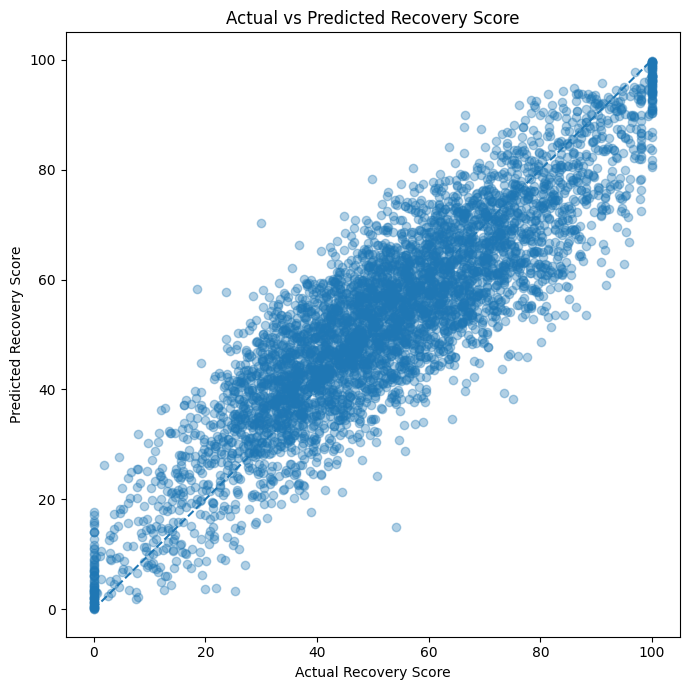

In [61]:
# Cell 24: Actual vs predicted Recovery Score

plt.figure(figsize=(7, 7))

plt.scatter(
    y_final_test,
    final_predictions,
    alpha=0.35
)

lower = min(
    y_final_test.min(),
    final_predictions.min()
)

upper = max(
    y_final_test.max(),
    final_predictions.max()
)

plt.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--"
)

plt.xlabel("Actual Recovery Score")
plt.ylabel("Predicted Recovery Score")
plt.title("Actual vs Predicted Recovery Score")

plt.tight_layout()
plt.show()

## 25. Residual analysis

Residual mean: -0.3597
Residual standard deviation: 10.0581


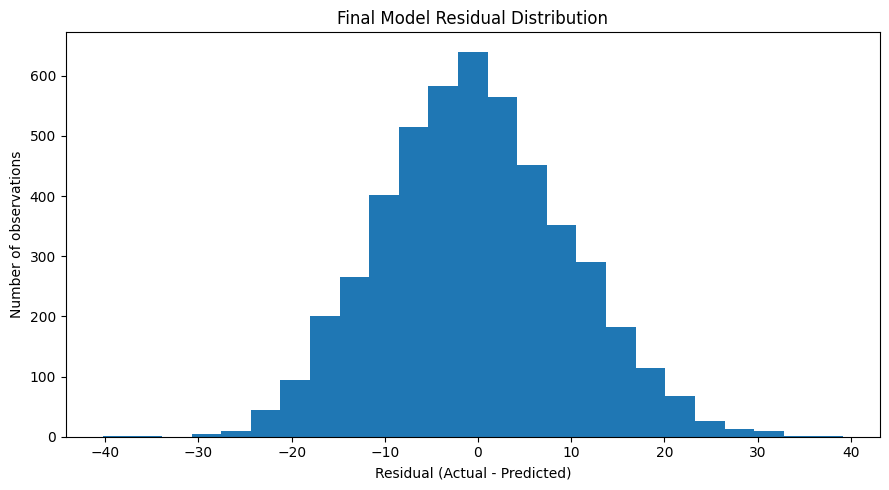

In [62]:
# Cell 25: Residual analysis

residuals = (
    y_final_test.to_numpy()
    - final_predictions
)

print("Residual mean:", round(residuals.mean(), 4))
print("Residual standard deviation:", round(residuals.std(), 4))

plt.figure(figsize=(9, 5))

plt.hist(
    residuals,
    bins=25
)

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Number of observations")
plt.title("Final Model Residual Distribution")

plt.tight_layout()
plt.show()

## 26. Final feature importance

In [63]:
# Cell 26: Final Extra Trees feature importance

extra_trees_model = final_model.named_steps["model"]
final_processor = final_model.named_steps["preprocessor"]

feature_names = (
    final_processor.get_feature_names_out()
)

importances = (
    extra_trees_model.feature_importances_
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(
    feature_importance_df.head(25).round(6)
)

,Feature,Importance
0,numeric__Sleep_Quality,0.272343
1,numeric__HRV_ms,0.224257
2,numeric__Energy_Level,0.076962
3,categorical__Source_Dataset_D3_Multimodal,0.057857
4,categorical__Stress_Level_High,0.053211
5,numeric__Sleep_Duration_Hours,0.048220
6,numeric__Sleep_Deficit,0.042515
7,categorical__Source_Dataset_D1_Recovery,0.037664
8,numeric__Fatigue_Index,0.022277
9,numeric__HRV_7d_Avg,0.018366


## 27. Feature importance plot

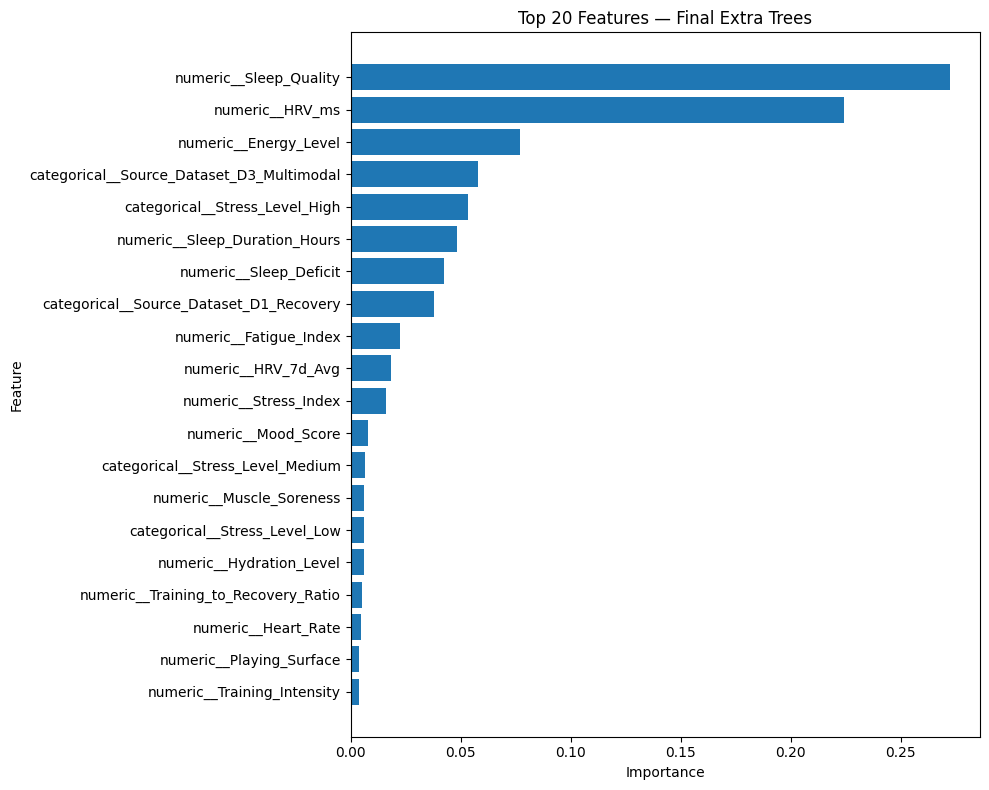

In [64]:
# Cell 27: Feature importance graph

top_features = (
    feature_importance_df
    .head(20)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features — Final Extra Trees")

plt.tight_layout()
plt.show()

28.

In [67]:
# Compatibility variable for later cells

cv_results_df = fast_cv_results_df

print("cv_results_df is now available.")

cv_results_df is now available.


In [68]:
# Cell 28: Save final ML artifacts

MODEL_DIR = (
    "/content/drive/MyDrive/"
    "AI Athlete Recovery ML"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "recovery_score_extra_trees.joblib"
)

CONFIG_PATH = os.path.join(
    MODEL_DIR,
    "recovery_model_config.json"
)

CV_RESULTS_PATH = os.path.join(
    MODEL_DIR,
    "model_comparison_grouped_cv.csv"
)

FINAL_RESULTS_PATH = os.path.join(
    MODEL_DIR,
    "final_test_results.csv"
)

SOURCE_RESULTS_PATH = os.path.join(
    MODEL_DIR,
    "source_wise_final_test_results.csv"
)

FEATURE_IMPORTANCE_PATH = os.path.join(
    MODEL_DIR,
    "feature_importance.csv"
)

# Save model pipeline
joblib.dump(
    final_model,
    MODEL_PATH
)

# Save model comparison
cv_results_df.to_csv(
    CV_RESULTS_PATH,
    index=False
)

# Save final metrics
final_metrics.to_csv(
    FINAL_RESULTS_PATH,
    index=False
)

# Save source-wise results
source_results_df.to_csv(
    SOURCE_RESULTS_PATH,
    index=False
)

# Save feature importance
feature_importance_df.to_csv(
    FEATURE_IMPORTANCE_PATH,
    index=False
)

# Save configuration
model_config = {
    "target": TARGET_COLUMN,
    "model_type": "ExtraTreesRegressor",
    "feature_columns": feature_columns,
    "reduced_feature_columns": reduced_feature_columns,
    "group_split_column": "Athlete_Key",
    "split_source": "supplied Split_Group",
    "random_seed": 42,
    "best_parameters": extra_trees_search.best_params_
}

with open(
    CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        model_config,
        file,
        indent=4
    )

print("Final model saved:")
print(MODEL_PATH)

print("\nConfiguration saved:")
print(CONFIG_PATH)

Final model saved:
/content/drive/MyDrive/AI Athlete Recovery ML/recovery_score_extra_trees.joblib

Configuration saved:
/content/drive/MyDrive/AI Athlete Recovery ML/recovery_model_config.json


## 28.Sensitivity analysis: remove heavily cross-source-filled features

In [70]:
# Cell 28: Fast sensitivity analysis
# Compare the final feature set with a reduced feature set.
# This is an additional robustness check, NOT the final model.

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import GroupKFold, cross_validate

# Reduced feature data
X_dev_reduced = df.loc[
    train_mask,
    reduced_feature_columns
].copy()

X_test_reduced = df.loc[
    test_mask,
    reduced_feature_columns
].copy()

# Identify feature types
numeric_reduced = X_dev_reduced.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_reduced = X_dev_reduced.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Reduced preprocessing
reduced_preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        numeric_reduced
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ))
        ]),
        categorical_reduced
    )
])

# Faster Extra Trees model
reduced_model = Pipeline([
    ("preprocessor", reduced_preprocessor),
    ("model", ExtraTreesRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# 3-fold grouped validation for sensitivity analysis
sensitivity_cv = GroupKFold(n_splits=3)

scores = cross_validate(
    reduced_model,
    X_dev_reduced,
    y_dev,
    groups=groups_dev,
    cv=sensitivity_cv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "mse": "neg_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1
)

reduced_cv_mae = -scores["test_mae"].mean()
reduced_cv_rmse = np.sqrt(-scores["test_mse"].mean())
reduced_cv_r2 = scores["test_r2"].mean()

# Fit reduced model once
reduced_model.fit(
    X_dev_reduced,
    y_dev
)

reduced_predictions = reduced_model.predict(
    X_test_reduced
)

reduced_test_mae = mean_absolute_error(
    y_final_test,
    reduced_predictions
)

reduced_test_rmse = np.sqrt(
    mean_squared_error(
        y_final_test,
        reduced_predictions
    )
)

reduced_test_r2 = r2_score(
    y_final_test,
    reduced_predictions
)

sensitivity_results = pd.DataFrame({
    "Model": [
        "Full Final Extra Trees",
        "Reduced Extra Trees"
    ],
    "CV MAE": [
        float(
            fast_cv_results_df.loc[
                fast_cv_results_df["Model"] == "Extra Trees",
                "CV MAE Mean"
            ].iloc[0]
        ),
        reduced_cv_mae
    ],
    "CV RMSE": [
        float(
            fast_cv_results_df.loc[
                fast_cv_results_df["Model"] == "Extra Trees",
                "CV RMSE Mean"
            ].iloc[0]
        ),
        reduced_cv_rmse
    ],
    "CV R2": [
        float(
            fast_cv_results_df.loc[
                fast_cv_results_df["Model"] == "Extra Trees",
                "CV R2 Mean"
            ].iloc[0]
        ),
        reduced_cv_r2
    ],
    "Final Test MAE": [
        final_mae,
        reduced_test_mae
    ],
    "Final Test RMSE": [
        final_rmse,
        reduced_test_rmse
    ],
    "Final Test R2": [
        final_r2,
        reduced_test_r2
    ]
})

display(
    sensitivity_results.round(4)
)

,Model,CV MAE,CV RMSE,CV R2,Final Test MAE,Final Test RMSE,Final Test R2
0,Full Final Extra Trees,8.0774,10.1970,0.7843,8.0382,10.0645,0.7789
1,Reduced Extra Trees,9.0794,11.4958,0.7260,8.8635,11.1620,0.7280


## 29. Reusable prediction function for Django

In [71]:
# Cell 29: Reusable Recovery Score prediction function

def predict_recovery_score(athlete_data: dict) -> float:
    """
    Predict Recovery_Score for one athlete observation.

    athlete_data must contain all features used by the final model.
    The returned value is a prediction on the dataset's 0-100
    Recovery_Score scale.
    """

    missing_features = [
        col
        for col in feature_columns
        if col not in athlete_data
    ]

    if missing_features:
        raise ValueError(
            "Missing required features: "
            + ", ".join(missing_features)
        )

    input_df = pd.DataFrame(
        [athlete_data],
        columns=feature_columns
    )

    prediction = final_model.predict(
        input_df
    )[0]

    # Keep prediction within the Recovery_Score scale.
    prediction = np.clip(
        prediction,
        0,
        100
    )

    return float(prediction)

## 30. Test the reusable prediction function

In [72]:
# Cell 30: Test the reusable prediction function

sample_athlete = X_final_test.iloc[0].to_dict()

predicted_score = predict_recovery_score(
    sample_athlete
)

actual_score = float(
    y_final_test.iloc[0]
)

print("=" * 50)
print("RECOVERY SCORE PREDICTION TEST")
print("=" * 50)

print(
    "Predicted Recovery_Score:",
    round(predicted_score, 2)
)

print(
    "Actual Recovery_Score:",
    round(actual_score, 2)
)

RECOVERY SCORE PREDICTION TEST
Predicted Recovery_Score: 82.82
Actual Recovery_Score: 80.3


## 31. Save the ML artifact and results

In [73]:
# Cell 31: Save final Extra Trees model and results

MODEL_DIR = (
    "/content/drive/MyDrive/"
    "AI Athlete Recovery ML"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

# Final trained model
MODEL_PATH = os.path.join(
    MODEL_DIR,
    "recovery_score_extra_trees.joblib"
)

# Model configuration
CONFIG_PATH = os.path.join(
    MODEL_DIR,
    "recovery_model_config.json"
)

# Results
CV_RESULTS_PATH = os.path.join(
    MODEL_DIR,
    "model_comparison_grouped_cv.csv"
)

FINAL_RESULTS_PATH = os.path.join(
    MODEL_DIR,
    "final_test_results.csv"
)

SOURCE_RESULTS_PATH = os.path.join(
    MODEL_DIR,
    "source_wise_final_test_results.csv"
)

FEATURE_IMPORTANCE_PATH = os.path.join(
    MODEL_DIR,
    "feature_importance.csv"
)


# Save final model
joblib.dump(
    final_model,
    MODEL_PATH
)


# Save model comparison
fast_cv_results_df.to_csv(
    CV_RESULTS_PATH,
    index=False
)


# Save final test results
final_metrics.to_csv(
    FINAL_RESULTS_PATH,
    index=False
)


# Save source-wise results
source_results_df.to_csv(
    SOURCE_RESULTS_PATH,
    index=False
)


# Save feature importance
feature_importance_df.to_csv(
    FEATURE_IMPORTANCE_PATH,
    index=False
)


# Save configuration
model_config = {
    "target": "Recovery_Score",
    "model_type": "ExtraTreesRegressor",
    "feature_columns": feature_columns,
    "reduced_feature_columns": reduced_feature_columns,
    "group_split_column": "Athlete_Key",
    "split_source": "supplied Split_Group",
    "random_seed": 42,
    "best_parameters": extra_trees_search.best_params_
}

with open(
    CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        model_config,
        file,
        indent=4
    )


print("=" * 60)
print("FINAL ML ARTIFACTS SAVED")
print("=" * 60)

print("\nModel:")
print(MODEL_PATH)

print("\nConfig:")
print(CONFIG_PATH)

print("\nCV results:")
print(CV_RESULTS_PATH)

print("\nFinal test results:")
print(FINAL_RESULTS_PATH)

print("\nSource-wise results:")
print(SOURCE_RESULTS_PATH)

print("\nFeature importance:")
print(FEATURE_IMPORTANCE_PATH)

FINAL ML ARTIFACTS SAVED

Model:
/content/drive/MyDrive/AI Athlete Recovery ML/recovery_score_extra_trees.joblib

Config:
/content/drive/MyDrive/AI Athlete Recovery ML/recovery_model_config.json

CV results:
/content/drive/MyDrive/AI Athlete Recovery ML/model_comparison_grouped_cv.csv

Final test results:
/content/drive/MyDrive/AI Athlete Recovery ML/final_test_results.csv

Source-wise results:
/content/drive/MyDrive/AI Athlete Recovery ML/source_wise_final_test_results.csv

Feature importance:
/content/drive/MyDrive/AI Athlete Recovery ML/feature_importance.csv


## 32. Reload and verify the saved model

In [74]:
# Cell 32: Reload and verify the saved model

loaded_model = joblib.load(
    MODEL_PATH
)

print(
    "Loaded model type:",
    type(
        loaded_model.named_steps["model"]
    ).__name__
)

reloaded_predictions = loaded_model.predict(
    X_final_test.head(10)
)

print("\nFirst 10 predictions:")

for value in reloaded_predictions:
    print(round(float(value), 2))

Loaded model type: ExtraTreesRegressor

First 10 predictions:
82.82
67.23
96.34
26.67
71.14
82.86
99.67
36.62
51.55
62.71


## 33. Final ML report summary

Use the actual values printed here in the project report.

The final test metrics are evaluation results for this dataset and split. They are not clinical validation or proof of real-world injury/recovery prediction performance.


In [75]:
# Cell 33: Final ML summary

print("=" * 70)
print("AI ATHLETE RECOVERY — FINAL ML SUMMARY")
print("=" * 70)

print("\nDataset")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Unique athletes:", df["Athlete_Key"].nunique())

print("\nTarget")
print("Recovery_Score")
print("Type: Regression")
print(
    "Range:",
    df["Recovery_Score"].min(),
    "to",
    df["Recovery_Score"].max()
)

print("\nFinal Model")
print("ExtraTreesRegressor")

print("\nBest Parameters")
print(extra_trees_search.best_params_)

print("\nBest Grouped-CV RMSE")
print(
    round(
        -extra_trees_search.best_score_,
        4
    )
)

print("\nFINAL UNTOUCHED TEST RESULTS")

print(
    "MAE :",
    round(final_mae, 4)
)

print(
    "RMSE:",
    round(final_rmse, 4)
)

print(
    "R2  :",
    round(final_r2, 4)
)

print("\nSource-wise results:")
display(
    source_results_df.round(4)
)

print("\nTop 10 features:")
display(
    feature_importance_df
    .head(10)
    .round(6)
)

print("\nSaved model:")
print(MODEL_PATH)

print("\nImportant limitation:")
print(
    "The supplied dataset is synthetic/simulated and contains "
    "substantial cross-source model-filled feature values. "
    "Results should be treated as prototype dataset performance, "
    "not real-world or clinical validation."
)

print("\n" + "=" * 70)

AI ATHLETE RECOVERY — FINAL ML SUMMARY

Dataset
Rows: 23799
Columns: 49
Unique athletes: 456

Target
Recovery_Score
Type: Regression
Range: 0.0 to 100.0

Final Model
ExtraTreesRegressor

Best Parameters
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 1.0, 'model__max_depth': 20}

Best Grouped-CV RMSE
10.1795

FINAL UNTOUCHED TEST RESULTS
MAE : 8.0382
RMSE: 10.0645
R2  : 0.7789

Source-wise results:


,Source,Rows,MAE,RMSE,R2
0,D1_Recovery,1674,7.4232,9.448,0.880
1,D3_Multimodal,3163,8.3637,10.376,0.641



Top 10 features:


,Feature,Importance
0,numeric__Sleep_Quality,0.272343
1,numeric__HRV_ms,0.224257
2,numeric__Energy_Level,0.076962
3,categorical__Source_Dataset_D3_Multimodal,0.057857
4,categorical__Stress_Level_High,0.053211
5,numeric__Sleep_Duration_Hours,0.048220
6,numeric__Sleep_Deficit,0.042515
7,categorical__Source_Dataset_D1_Recovery,0.037664
8,numeric__Fatigue_Index,0.022277
9,numeric__HRV_7d_Avg,0.018366



Saved model:
/content/drive/MyDrive/AI Athlete Recovery ML/recovery_score_extra_trees.joblib

Important limitation:
The supplied dataset is synthetic/simulated and contains substantial cross-source model-filled feature values. Results should be treated as prototype dataset performance, not real-world or clinical validation.



34.

In [76]:
# Cell 34: Record exact package versions

import sys
import sklearn
import pandas
import numpy
import joblib

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("joblib:", joblib.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
scikit-learn: 1.6.1
pandas: 2.2.3
numpy: 2.1.3
joblib: 1.6.0


35.

In [77]:
# Cell 35: FINAL ML MODEL AUDIT

import os
import sys
import sklearn
import pandas
import numpy
import joblib

print("=" * 70)
print("FINAL ML MODEL AUDIT")
print("=" * 70)

# ---------------------------------------------------------
# 1. Dataset
# ---------------------------------------------------------

print("\n[1] DATASET")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Unique athletes:", df["Athlete_Key"].nunique())
print("Target:", TARGET_COLUMN)

# ---------------------------------------------------------
# 2. Split
# ---------------------------------------------------------

print("\n[2] SPLIT")
print("Development rows:", len(X_dev))
print("Final test rows:", len(X_final_test))
print("Development athletes:", groups_dev.nunique())
print(
    "Final test athletes:",
    df.loc[test_mask, "Athlete_Key"].nunique()
)

train_athletes = set(
    df.loc[train_mask, "Athlete_Key"]
)

test_athletes = set(
    df.loc[test_mask, "Athlete_Key"]
)

print(
    "Athlete overlap:",
    len(train_athletes.intersection(test_athletes))
)

# ---------------------------------------------------------
# 3. Final model
# ---------------------------------------------------------

print("\n[3] FINAL MODEL")

print(
    "Model type:",
    type(
        final_model.named_steps["model"]
    ).__name__
)

print("\nBest parameters:")
for key, value in extra_trees_search.best_params_.items():
    print(f"{key}: {value}")

print(
    "\nBest grouped-CV RMSE:",
    round(
        -extra_trees_search.best_score_,
        4
    )
)

# ---------------------------------------------------------
# 4. Final test results
# ---------------------------------------------------------

print("\n[4] FINAL UNTOUCHED TEST RESULTS")

print(
    "MAE :",
    round(final_mae, 4)
)

print(
    "RMSE:",
    round(final_rmse, 4)
)

print(
    "R2  :",
    round(final_r2, 4)
)

# ---------------------------------------------------------
# 5. Source-wise results
# ---------------------------------------------------------

print("\n[5] SOURCE-WISE FINAL RESULTS")

display(
    source_results_df.round(4)
)

# ---------------------------------------------------------
# 6. Sensitivity analysis
# ---------------------------------------------------------

print("\n[6] SENSITIVITY ANALYSIS")

if "sensitivity_results" in globals():
    display(
        sensitivity_results.round(4)
    )
else:
    print("Sensitivity results variable not found.")

# ---------------------------------------------------------
# 7. Feature importance
# ---------------------------------------------------------

print("\n[7] TOP 15 FEATURES")

display(
    feature_importance_df
    .head(15)
    .round(6)
)

# ---------------------------------------------------------
# 8. Model artifact
# ---------------------------------------------------------

print("\n[8] SAVED MODEL")

print("Model path:")
print(MODEL_PATH)

print(
    "Model file exists:",
    os.path.exists(MODEL_PATH)
)

print("\nConfig path:")
print(CONFIG_PATH)

print(
    "Config file exists:",
    os.path.exists(CONFIG_PATH)
)

# ---------------------------------------------------------
# 9. Package versions
# ---------------------------------------------------------

print("\n[9] ENVIRONMENT")

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("joblib:", joblib.__version__)

print("\n" + "=" * 70)
print("AUDIT COMPLETE")
print("=" * 70)

FINAL ML MODEL AUDIT

[1] DATASET
Rows: 23799
Columns: 49
Unique athletes: 456
Target: Recovery_Score

[2] SPLIT
Development rows: 18962
Final test rows: 4837
Development athletes: 364
Final test athletes: 92
Athlete overlap: 0

[3] FINAL MODEL
Model type: ExtraTreesRegressor

Best parameters:
model__n_estimators: 200
model__min_samples_split: 2
model__min_samples_leaf: 4
model__max_features: 1.0
model__max_depth: 20

Best grouped-CV RMSE: 10.1795

[4] FINAL UNTOUCHED TEST RESULTS
MAE : 8.0382
RMSE: 10.0645
R2  : 0.7789

[5] SOURCE-WISE FINAL RESULTS


,Source,Rows,MAE,RMSE,R2
0,D1_Recovery,1674,7.4232,9.448,0.880
1,D3_Multimodal,3163,8.3637,10.376,0.641



[6] SENSITIVITY ANALYSIS


,Model,CV MAE,CV RMSE,CV R2,Final Test MAE,Final Test RMSE,Final Test R2
0,Full Final Extra Trees,8.0774,10.1970,0.7843,8.0382,10.0645,0.7789
1,Reduced Extra Trees,9.0794,11.4958,0.7260,8.8635,11.1620,0.7280



[7] TOP 15 FEATURES


,Feature,Importance
0,numeric__Sleep_Quality,0.272343
1,numeric__HRV_ms,0.224257
2,numeric__Energy_Level,0.076962
3,categorical__Source_Dataset_D3_Multimodal,0.057857
4,categorical__Stress_Level_High,0.053211
5,numeric__Sleep_Duration_Hours,0.048220
6,numeric__Sleep_Deficit,0.042515
7,categorical__Source_Dataset_D1_Recovery,0.037664
8,numeric__Fatigue_Index,0.022277
9,numeric__HRV_7d_Avg,0.018366



[8] SAVED MODEL
Model path:
/content/drive/MyDrive/AI Athlete Recovery ML/recovery_score_extra_trees.joblib
Model file exists: True

Config path:
/content/drive/MyDrive/AI Athlete Recovery ML/recovery_model_config.json
Config file exists: True

[9] ENVIRONMENT
Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
scikit-learn: 1.6.1
pandas: 2.2.3
numpy: 2.1.3
joblib: 1.6.0

AUDIT COMPLETE
